# Рубежный контроль №1
**Выполнила:** Каверина Софья, группа ИУ5-66Б  
**Вариант:** 7 
**Задача:** 1 Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель. Дополнительно для группы ИУ5-66Б - для набора данных построить "парные диаграммы". 
**Набор данных:** 7 (Google Play Store Apps на Kaggle)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "/home/cherry4xo/Documents/goKittyGo/RK1/googleplaystore.csv" 
data = pd.read_csv(url)

print("Размерность исходного датасета:", data.shape)
data = data[data['Reviews'] != '3.0M']

data['Reviews'] = pd.to_numeric(data['Reviews'])

data['Installs'] = data['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
data['Installs'] = pd.to_numeric(data['Installs'])

data['Price'] = data['Price'].str.replace('$', '', regex=False)
data['Price'] = pd.to_numeric(data['Price'])

data_cleaned = data.dropna(axis=0)

print("Размерность ПОСЛЕ удаления строк с пропусками:", data_cleaned.shape)

Размерность исходного датасета: (10841, 13)
Размерность ПОСЛЕ удаления строк с пропусками: (9360, 13)


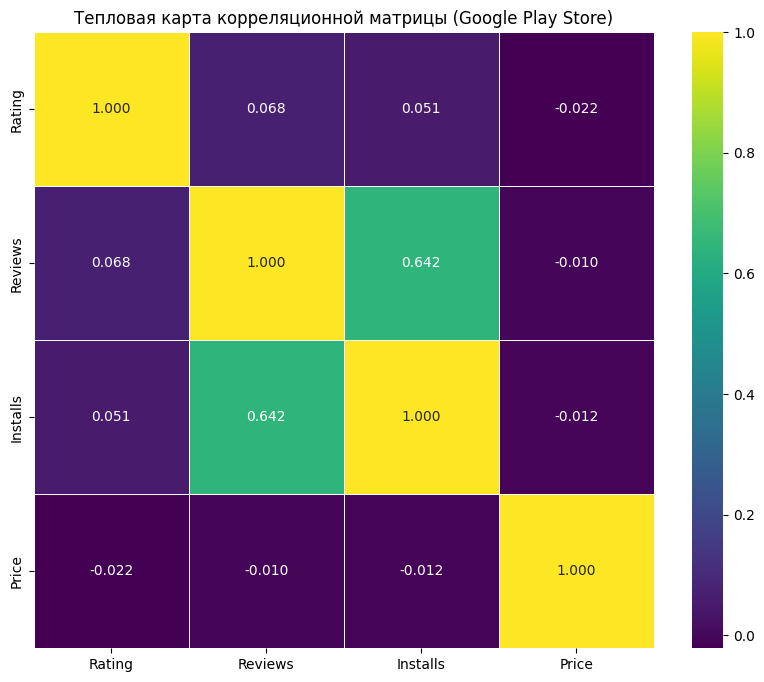

In [2]:
numeric_features = ['Rating', 'Reviews', 'Installs', 'Price']
corr_matrix = data_cleaned[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".3f", linewidths=0.5)
plt.title('Тепловая карта корреляционной матрицы (Google Play Store)')
plt.show()

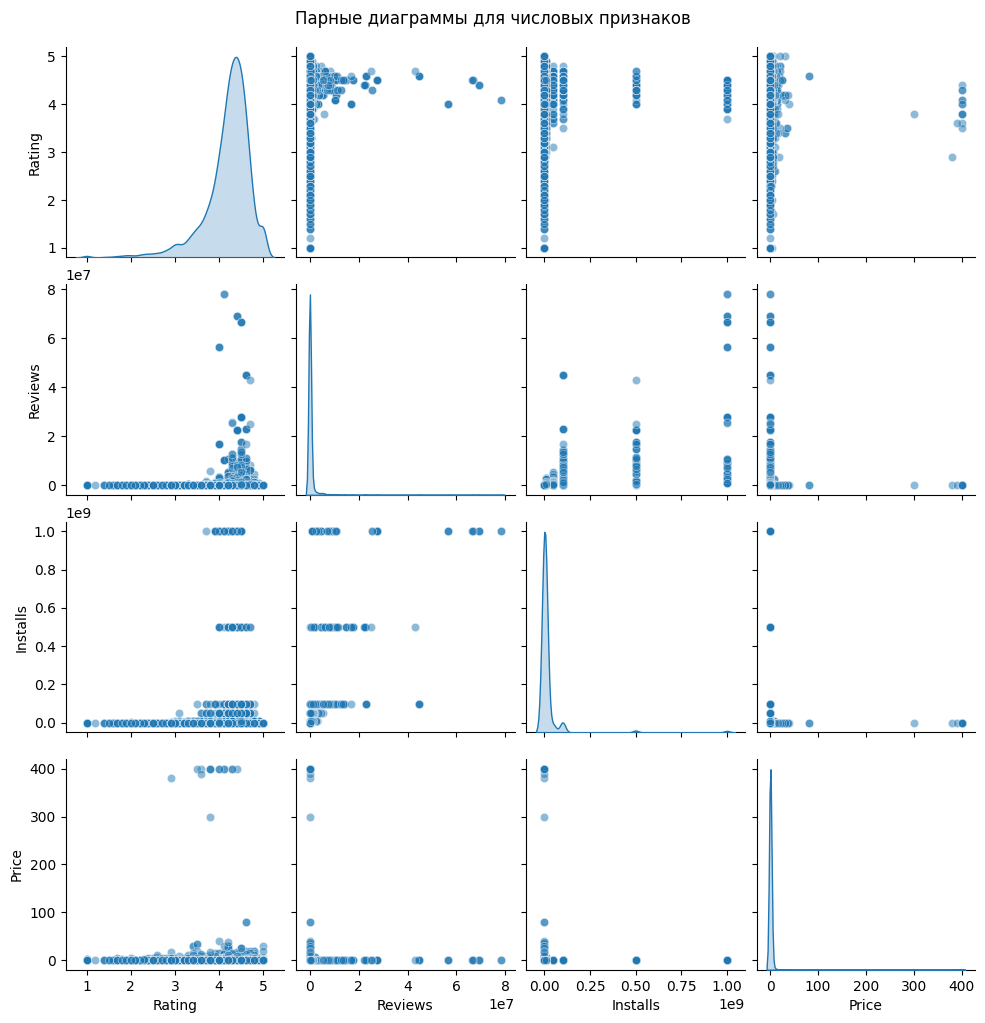

In [3]:
sns.pairplot(data_cleaned[numeric_features], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Парные диаграммы для числовых признаков', y=1.02)
plt.show()

### Выводы по результатам разведочного анализа:

**1. Обработка пропусков:**
Исходный датасет содержал значительное количество пропусков (в основном отсутствовали оценки приложений — колонка `Rating`). Согласно условию, они были обработаны методом удаления строк (`dropna`). Итоговый размер данных составил более 9300 строк, чего абсолютно достаточно для дальнейшего машинного обучения. Перед анализом потребовалась конвертация некоторых признаков (Price, Installs, Reviews) из строкового типа в числовой.

**2. Вклад признаков в модель:**
Если в качестве целевой переменной выбрать **Rating** (рейтинг приложения) или **Installs** (количество установок), корреляционный анализ показывает следующее:
* **Reviews и Installs:** Имеют самую сильную положительную связь в датасете ($r \approx 0.64$). Это логично: чем больше раз скачивают приложение, тем больше отзывов пользователи оставляют.
* **Rating (Рейтинг):** Имеет очень слабую положительную корреляцию с количеством отзывов и установок (около $0.05 - 0.07$). Это означает, что популярность приложения (число скачиваний) не гарантирует его высокое качество (рейтинг).
* **Price (Цена):** Имеет слабую отрицательную корреляцию с количеством установок и отзывами. Платные приложения скачивают реже, что является ожидаемым поведением рынка.

**3. Мультиколлинеарность:**
Признаки `Reviews` (отзывы) и `Installs` (установки) сильно коррелируют друг с другом. В случае построения чувствительных к мультиколлинеарности моделей (например, линейной или логистической регрессии), один из этих признаков рекомендуется исключить.

**4. Возможность построения моделей машинного обучения:**
Данные можно использовать для задач регрессии (прогнозирование рейтинга) или классификации (например, будет ли приложение иметь более 1 млн установок). Однако, поскольку линейные связи между целевой переменной `Rating` и остальными числовыми признаками очень слабые (что видно на тепловой карте и парных диаграммах), простые линейные модели покажут низкую эффективность. Для получения качественных предсказаний потребуется использовать нелинейные модели (деревья решений, случайный лес) и обязательно подключить категориальные признаки, предварительно закодировав их (One-Hot Encoding).